<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week5_Day2_Exercices_XP_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | Manual and domain-specific | Automated (Representation Learning) |
| Data Processing | Small to medium structured datasets | Massive unstructured datasets (Big Data) |
| Scalability | Limited; performance plateaus | Highly scalable with more data/compute |
| Pattern Discovery | Linear or simple non-linear | Complex, hierarchical features |
| Computational Requirements | Low (CPU) | High (GPU/TPU) |

**Traditional ML:** Better for credit scoring with structured bank data, where interpretability and smaller datasets are common.
**Deep Learning:** Better for autonomous driving (image recognition), where the model must process high-dimensional unstructured visual data to find complex patterns.

Deep learning excels at unstructured data because of **representation learning**, which eliminates the need for manual feature extraction. It automatically builds **hierarchical features**, where early layers detect simple edges and later layers identify complex objects. This allows the model to handle raw pixels, text, or audio directly with high accuracy.

## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.



In forward propagation, the **inputs** are multiplied by **weights** and added to **biases** at each neuron. This **weighted sum** is passed through an **activation function** (like ReLU) to introduce non-linearity. The resulting values are then passed as inputs to the next layer until they reach the **outputs**.

**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [ ]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [ ]:
y = -(x**2) + np.random.normal(0, 0.05, len(x))
print("y shape:", y.shape)

y shape: (20,)


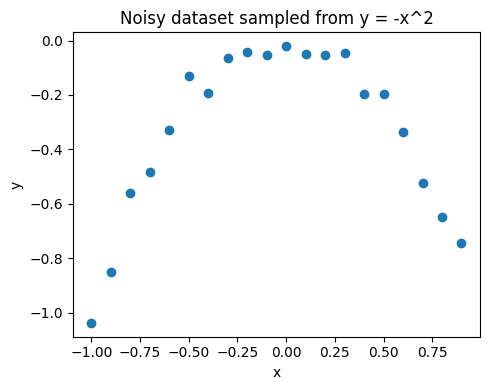

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure data is generated before plotting
x = np.arange(-1, 1, 0.1)
y = -(x**2) + np.random.normal(0, 0.05, len(x))

plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [ ]:
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]
print("train sizes:", x_train.shape, y_train.shape, "test sizes:", x_test.shape, y_test.shape)

train sizes: (12,) (12,) test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [ ]:
def polynomial_fit(degree: int):
    coeffs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coeffs)

In [ ]:
def plot_polyfit(degree: int):
    model = polynomial_fit(degree)
    x_dense = np.linspace(-1, 1, 100)
    y_dense = model(x_dense)

    plt.figure(figsize=(6, 4))
    plt.scatter(x_train, y_train, color='blue', label='Train')
    plt.scatter(x_test, y_test, color='red', label='Test')
    plt.plot(x_dense, y_dense, color='green', label=f'Degree {degree}')
    plt.title(f"Polynomial Fit (Degree {degree})")
    plt.legend()
    plt.show()

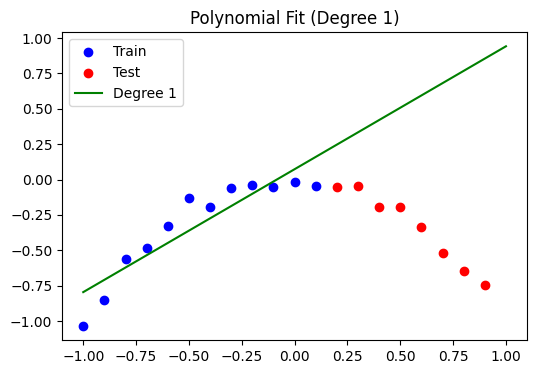

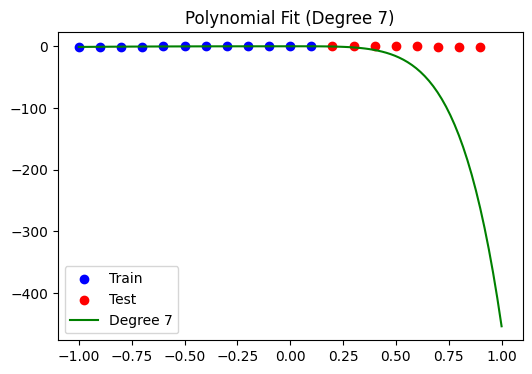

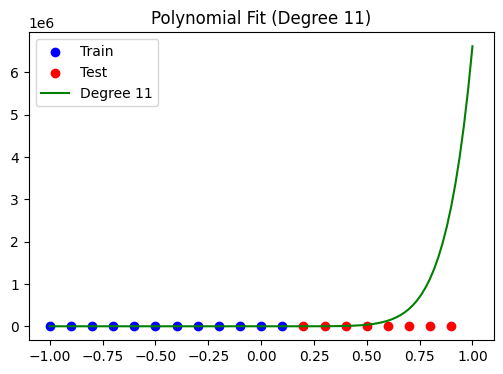

In [ ]:
for d in [1, 7, 11]:
    plot_polyfit(d)

**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [ ]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 12)
rows = []
for d in degrees:
    model = np.poly1d(np.polyfit(x_train, y_train, d))
    rmse_train = rmse(y_train, model(x_train))
    rmse_test = rmse(y_test, model(x_test))
    rows.append((d, rmse_train, rmse_test))

display(rows[:3])

[(1, np.float64(0.1387838767653551), np.float64(0.9992395957549253)),
 (2, np.float64(0.039855000967891345), np.float64(0.3154750076040755)),
 (3, np.float64(0.0369320242141064), np.float64(0.2595286182071002))]

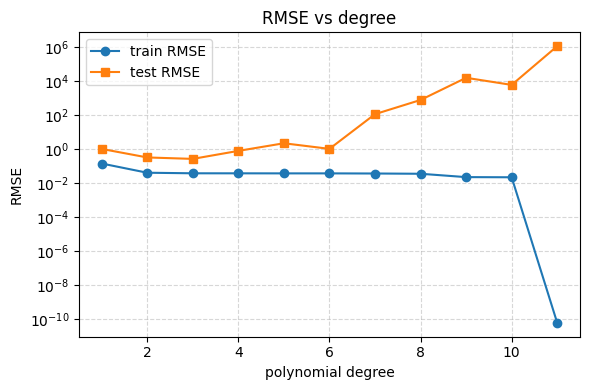

In [ ]:
degs = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]

plt.figure(figsize=(6,4))
plt.plot(degs, rmse_tr, label="train RMSE", marker='o')
plt.plot(degs, rmse_te, label="test RMSE", marker='s')
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("RMSE")
plt.title("RMSE vs degree")
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Report:** The degree with the minimum test RMSE is **2**.

This connects to the true model because our original function was $y = -x^2$, which is a degree 2 polynomial. The **bias-variance tradeoff** is visible here: degree 1 has high bias (underfitting), while degrees > 2 show high variance (overfitting), capturing noise instead of the signal.